In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
def load_dataset(file_path):
    try:
        data = pd.read_csv(file_path)
        print("Dataset loaded successfully!")
        return data
    
    except FileNotFoundError:
        print(f"File not found: {file_path}. Please ensure the file exists in the specified path.")
        return None
    raise NotImplementedError()
    
data = load_dataset("/Users/thandiwemtshweni/Desktop/data_files/SuperStore_data.csv")

Dataset loaded successfully!


In [2]:
def get_dataset_shape(data):
    shape = data.shape
    print(f"Shape of the dataset: {shape}")
    return shape
    raise NotImplementedError()
#Test cases provided by Zaio Institute of Technology to test my work
shape = get_dataset_shape(data)
isinstance(shape, tuple)
print(len(shape))

Shape of the dataset: (10296, 21)
2


In [3]:
def get_column_types(data):
    # YOUR CODE HERE   
    for col in data.columns:
        if "date" in col.lower():
            original_non_null = data[col].notna().sum()
            data[col] = pd.to_datetime(data[col], errors='coerce')
            converted_non_null = data[col].notna().sum()

            if converted_non_null < original_non_null:
                print("Warning: Cannot convert to date")

    numerical_cols = data.select_dtypes(include='number').columns.tolist()
    datetime_cols = data.select_dtypes(include='datetime64[ns]').columns.tolist()
    categorical_cols = data.select_dtypes(
        include=['object', 'category', 'bool', 'str']
    ).columns.tolist()

    return numerical_cols, categorical_cols, datetime_cols
    raise NotImplementedError()
#Test cases provided by Zaio Institute of Technology to test my work
numerical, categorical, datetime = get_column_types(data)
print(isinstance(numerical, list))
print(isinstance(categorical, list))
print(isinstance(datetime, list))

True
True
True


In [4]:
def calculate_missing_values(data):
    missing_values = data.isna().sum()
    percentage = (missing_values/len(data)) * 100
    missing_data = pd.DataFrame({"Missing Values": missing_values,
           "Percentage": percentage})
    return missing_data
    raise NotImplementedError()
#Test cases provided by Zaio Institute of Technology to test my work
missing_summary = calculate_missing_values(data)
isinstance(missing_summary, pd.DataFrame)
print("Missing Values" in missing_summary.columns)
print("Percentage" in missing_summary.columns)

True
True


In [5]:
import numpy as np
def identify_outliers(data):
    numerical_cols = data.select_dtypes(include=[np.number]).columns
    
    results = []
    
    for col in numerical_cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers_below = int((data[col] < lower_bound).sum())
        outliers_above = int((data[col] > upper_bound).sum())
        
        results.append({
            'Column': col,
            'Outliers Below': outliers_below,
            'Outliers Above': outliers_above,
            'Total Outliers': outliers_below + outliers_above
        })
        result_df = pd.DataFrame(results).set_index('Column')
        result_df.index.name = None
    
        return result_df
        raise NotImplementedError()
#Test cases provided by Zaio Institute of Technology to test my work
outlier_summary = identify_outliers(data)
isinstance(outlier_summary, pd.DataFrame)

print("Outliers Below" in outlier_summary.columns)
print("Outliers Above" in outlier_summary.columns)

True
True


In [6]:
def handle_outliers(data):
    numerical = data.select_dtypes(include="number")
    Q1 = numerical.quantile(0.25)
    Q3 = numerical.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[numerical.columns] = numerical.clip(
        lower_bound,
        upper_bound,
        axis = 1
    )
    return data
    raise NotImplementedError()
#Test cases provided by Zaio Institute of Technology to test my work
modified_data = handle_outliers(data)
isinstance(modified_data, pd.DataFrame)
print(modified_data.shape[1])
upper_bound_sales = data['Sales'].quantile(0.75) + 1.5 * (data['Sales'].quantile(0.75) - data['Sales'].quantile(0.25))
print((modified_data['Sales'] > upper_bound_sales).sum())

21
0


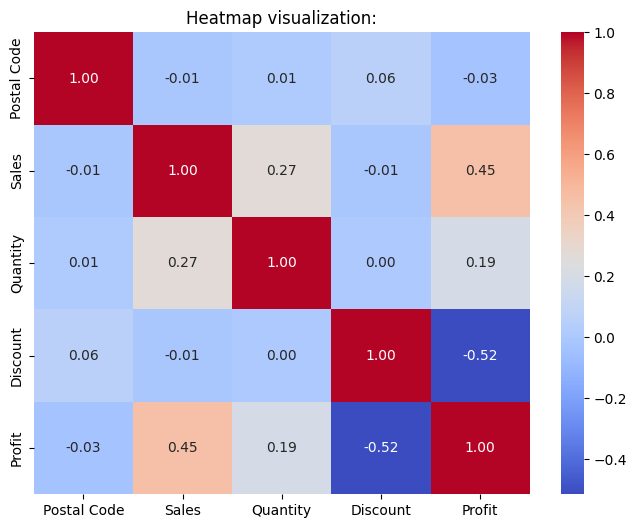

np.True_

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_correlations(data):
    numerical = data.select_dtypes(include="number")

    corr_matrix = numerical.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Heatmap visualization:")
    plt.show()
    return corr_matrix
    raise NotImplementedError()
correlation_matrix = analyze_correlations(data)
isinstance(correlation_matrix, pd.DataFrame)
numerical_columns = data.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix.shape == (len(numerical_columns), len(numerical_columns))
(correlation_matrix.values.diagonal() == 1).all()

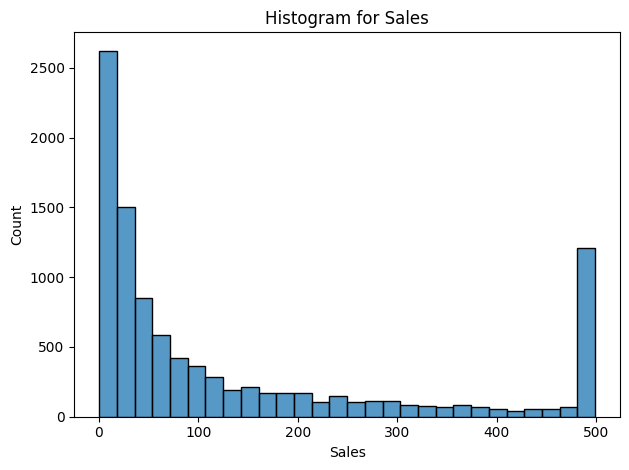

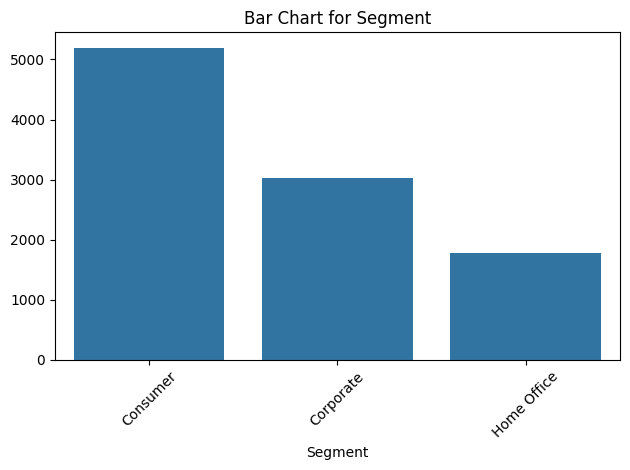

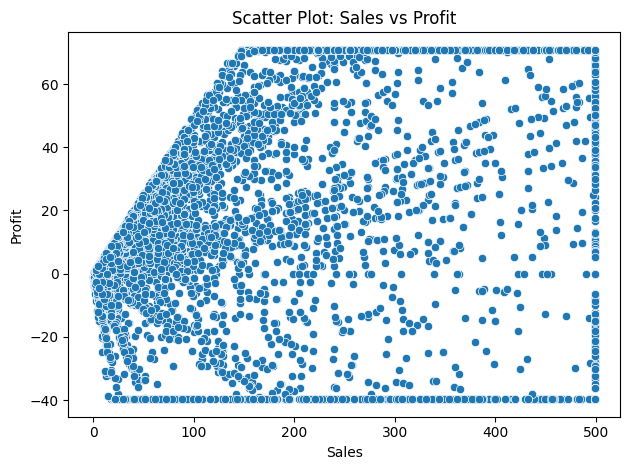

In [8]:
import matplotlib.pyplot as plt

def plot_univariate(data, column):
    if column not in data.columns:
        print(f"Column '{column}' does not exist in dataset.")
        return

    plt.figure()
    if pd.api.types.is_numeric_dtype(data[column]):
        sns.histplot(data=data, x=column)
        plt.title(f"Histogram for {column}")
    else:
        counts = data[column].value_counts()
        sns.barplot(x=counts.index, y=counts.values)
        plt.title(f"Bar Chart for {column}")
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()
def plot_bivariate(data, column_x, column_y):
  
    if column_x not in data.columns or column_y not in data.columns:
        print("One or both columns do not exist in dataset.")
        return

    plt.figure()

    x_numeric = pd.api.types.is_numeric_dtype(data[column_x])
    y_numeric = pd.api.types.is_numeric_dtype(data[column_y])
    if x_numeric and y_numeric:
        sns.scatterplot(data=data, x=column_x, y=column_y)
        plt.title(f"Scatter Plot: {column_x} vs {column_y}")
    elif x_numeric and not y_numeric:
        sns.boxplot(data=data, x=column_y, y=column_x)
        plt.title(f"Box Plot: {column_y} vs {column_x}")

    elif not x_numeric and y_numeric:
        sns.boxplot(data=data, x=column_x, y=column_y)
        plt.title(f"Box Plot: {column_x} vs {column_y}")
    else:
        print("Both columns are categorical. No visualization specified.")
        return

    plt.tight_layout()
    plt.show()
(plot_univariate(data, "Sales"))
(plot_univariate(data, "Segment"))
plot_bivariate(data, "Sales", "Profit")